In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

In [76]:
#inportamos la data
df=pd.read_csv("marketing_campaign.csv",sep="\t")

In [77]:
#informacion del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [78]:
#verificamos el dataset
df.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0


LIMPIEZA DE DATOS Y TRANSFORMACION

In [79]:
df=df.drop_duplicates()

In [80]:
df=df.dropna(subset=['Income'])

In [81]:
df['AGE']=2026-df['Year_Birth']

In [82]:
df['total']=(df['MntFishProducts']+
             df['MntFruits']+df['MntMeatProducts']+
             df['MntSweetProducts']+df['MntWines']+
             df['MntGoldProds'])

In [83]:
df['total_compras']=df['NumWebPurchases']+df['NumCatalogPurchases']+df['NumStorePurchases']

In [84]:
#escogemos valores importante para entrenar los datos y separar por clusteres
x=df[['total','total_compras','Income','AGE']]

In [85]:
#Normalizamos los datos para que todas las variables tengan la misma escala
scaler=StandardScaler()
xscaled=scaler.fit_transform(x)

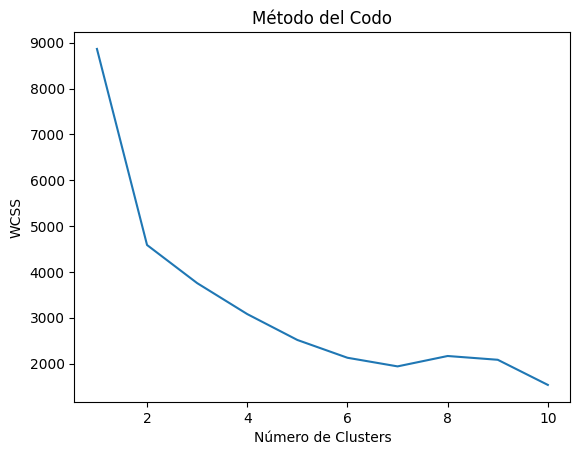

In [86]:
# Aplicamos el Método del Codo para encontrar el número óptimo de clusters
# El Método del Codo consiste en graficar la WCSS y buscar el punto
# donde la disminución empieza a ser pequeña (el "codo"), indicando un buen número de clusters
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(xscaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Método del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("WCSS")
plt.show()

In [87]:
#Creamos y entrenamos el modelo K-Means con 4 clusters
kmeans =KMeans(n_clusters=4,random_state=42)
df['cluster']=kmeans.fit_predict(xscaled)#Asignamos cada cliente a un cluster

In [88]:
#Analizamos los clusters por promedio de las variables clave
df.groupby('cluster')[['total','total_compras','Income','AGE']].mean()

,total,total_compras,Income,AGE
cluster,,,,
0,117.833992,6.321476,32952.449275,48.467721
1,1148.630480,19.405010,69858.129436,69.505219
2,198.104478,8.339019,43267.742004,67.567164
3,1203.807466,19.298625,72719.813360,49.000000


In [89]:
# Asignamos etiquetas descriptivas a cada cluster
condiciones=[(df['cluster']==0),(df['cluster']==1),(df['cluster']==2),(df['cluster']==3)]
seleciones=['Bajo ingreso / Bajo gasto','Clientes Premium','Alto ingreso / Bajo gasto','Clientes Jóvenes Digitales']

df['categoria']=np.select(condiciones,seleciones,default='otros')

In [90]:
df.groupby('categoria')[['total','total_compras','Income','AGE']].mean().sort_values(by='total',ascending=False)

,total,total_compras,Income,AGE
categoria,,,,
Clientes Jóvenes Digitales,1203.807466,19.298625,72719.813360,49.000000
Clientes Premium,1148.630480,19.405010,69858.129436,69.505219
Alto ingreso / Bajo gasto,198.104478,8.339019,43267.742004,67.567164
Bajo ingreso / Bajo gasto,117.833992,6.321476,32952.449275,48.467721


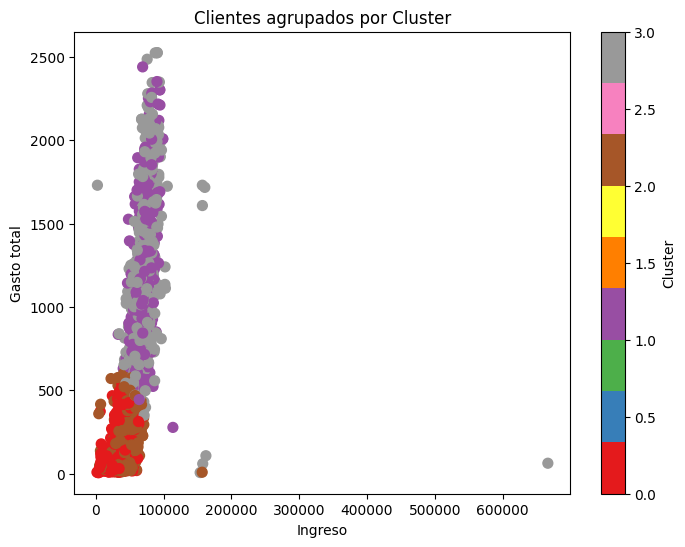

In [91]:

# Crear figura para poder analize por ingreso vs gasto total por clusteres
plt.figure(figsize=(8,6))
plt.scatter(df['Income'], df['total'], c=df['cluster'], cmap='Set1', s=50)
plt.title("Clientes agrupados por Cluster")
plt.xlabel("Ingreso")
plt.ylabel("Gasto total")
plt.colorbar(label='Cluster')
plt.show()